In [1]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df, model_wide_accuracy_df, question_wide_accuracy_df, firac_order, model_order = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)
print('firac_order', firac_order)
                                                                                                                                                                        
question_long_df.head(1)


shape (1971, 30)
firac_order ['FILA_', 'FIL__', 'FI___', '_____']


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,...,D,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds
0,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-178.pdf,oab-178.pdf-258,DIREITO CIVIL,XXXVII,258,C,...,A realização de Assembleia Geral por meio elet...,"{\n ""F"": ""['A Associação Atlética de uma renom...",['A Associação Atlética de uma renomada instit...,É válida a realização de Assembleia Geral por ...,Art. 48-A do Código Civil,As pessoas jurídicas de direito privado têm a ...,A realização de Assembleia Geral por meio elet...,1,6,3.143256


In [2]:
model_wide_accuracy_df.head(100)

firac,FILA_,FIL__,FI___,_____
model_name,,,,
gemini-2.0-flash-lite,0.991935,0.856061,0.819820,0.796875
gemma-3-12b-it,0.965035,0.696552,0.682759,0.595890
gemma-3-27b-it,0.971429,0.713287,0.736111,0.657534
gemma-3-4b-it,0.855422,0.634146,0.564516,0.518072
gemma-3n-e4b-it,1.000000,0.500000,1.000000,0.666667


In [3]:
question_wide_accuracy_df

firac,FILA_,FIL__,FI___,_____
question_id,,,,
oab-153.pdf-007,1.0,0.333333,0.00,0.333333
oab-153.pdf-014,1.0,0.500000,0.50,0.666667
oab-154.pdf-019,1.0,1.000000,1.00,1.000000
oab-154.pdf-021,1.0,1.000000,1.00,1.000000
oab-154.pdf-023,1.0,0.000000,0.00,0.000000
...,...,...,...,...
oab-85.pdf-090,1.0,1.000000,1.00,1.000000
oab-85.pdf-091,1.0,0.666667,1.00,0.750000
oab-85.pdf-093,1.0,1.000000,1.00,1.000000


Existe missing data?

In [4]:
question_long_df.isna().sum()


model_name                 0
firac                      0
language                   0
is_correct                 0
pdf_filename               0
question_id                0
materia                    0
oab_test_id                0
oab_question_id            0
chosen_option              0
correct_option             0
enunciado                  0
prompt                     0
finish_reason              0
avg_logprobs               0
input_token_count          0
output_token_count         0
A                          0
B                          0
C                          0
D                          0
full_response              0
Facts                      0
Issue                      0
Rule                       2
Application               36
Conclusion               352
rule_count                 0
fact_count                 0
response_time_seconds      0
dtype: int64

In [5]:
question_long_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model_name             1971 non-null   object 
 1   firac                  1971 non-null   object 
 2   language               1971 non-null   object 
 3   is_correct             1971 non-null   bool   
 4   pdf_filename           1971 non-null   object 
 5   question_id            1971 non-null   object 
 6   materia                1971 non-null   object 
 7   oab_test_id            1971 non-null   object 
 8   oab_question_id        1971 non-null   int64  
 9   chosen_option          1971 non-null   object 
 10  correct_option         1971 non-null   object 
 11  enunciado              1971 non-null   object 
 12  prompt                 1971 non-null   object 
 13  finish_reason          1971 non-null   object 
 14  avg_logprobs           1971 non-null   float64
 15  inpu

Acurácia por modelo

In [6]:
accuracy_by_model = (
    question_long_df.groupby('model_name')['is_correct']
      .mean()
      .sort_values(ascending=False)
)

accuracy_by_model

model_name
gemini-2.0-flash-lite    0.866667
gemma-3n-e4b-it          0.785714
gemma-3-27b-it           0.767888
gemma-3-12b-it           0.734024
gemma-3-4b-it            0.648387
Name: is_correct, dtype: float64

Acuráca por nível FIRAC

In [7]:
accuracy_by_model = (
    question_long_df.groupby('firac')['is_correct']
      .mean()
      .sort_values(ascending=False)
)

accuracy_by_model

firac
FILA_    0.955556
FIL__    0.731225
FI___    0.717672
_____    0.652174
Name: is_correct, dtype: float64

In [8]:
import pandas as pd

# --- Função de classificação pela CTT ---
def classify_difficulty(acc):
    if acc >= 0.80:
        return 'muito fácil'
    elif acc >= 0.60:
        return 'fácil'
    elif acc >= 0.40:
        return 'média'
    elif acc >= 0.20:
        return 'difícil'
    else:
        return 'muito difícil'

# -------------------------------------------------
# TABELA 1: Considerando TODAS as questões
# -------------------------------------------------

df_question = (
    question_long_df.groupby('question_id')['is_correct']
      .mean()
      .reset_index(name='accuracy')
)

df_question['difficulty'] = df_question['accuracy'].apply(classify_difficulty)

difficulty_dist_all = (
    df_question
    .groupby('difficulty')
    .agg(
        count=('question_id', 'count'),
        mean_accuracy=('accuracy', 'mean')
    )
)

difficulty_dist_all['percent'] = (
    difficulty_dist_all['count'] / difficulty_dist_all['count'].sum() * 100
).round(2)

difficulty_dist_all['mean_accuracy'] = difficulty_dist_all['mean_accuracy'].round(3)
difficulty_dist_all = difficulty_dist_all.sort_values(by='mean_accuracy', ascending=False)

print("=== Distribuição para TODAS as questões ===")
print(difficulty_dist_all)


# -------------------------------------------------
# TABELA 2: Apenas questões com firac == "_____"
# -------------------------------------------------

df_firac_blank = question_long_df[question_long_df['firac'] == "____"]

df_question_blank = (
    df_firac_blank.groupby('question_id')['is_correct']
      .mean()
      .reset_index(name='accuracy')
)

df_question_blank['difficulty'] = df_question_blank['accuracy'].apply(classify_difficulty)

difficulty_dist_blank = (
    df_question_blank
    .groupby('difficulty')
    .agg(
        count=('question_id', 'count'),
        mean_accuracy=('accuracy', 'mean')
    )
)

difficulty_dist_blank['percent'] = (
    difficulty_dist_blank['count'] / difficulty_dist_blank['count'].sum() * 100
).round(2)

difficulty_dist_blank['mean_accuracy'] = difficulty_dist_blank['mean_accuracy'].round(3)
difficulty_dist_blank = difficulty_dist_blank.sort_values(by='mean_accuracy', ascending=False)

print("\n=== Distribuição para questões com firac == '____' ===")
print(difficulty_dist_blank)


=== Distribuição para TODAS as questões ===
               count  mean_accuracy  percent
difficulty                                  
muito fácil       82          0.949    55.78
fácil             29          0.693    19.73
média             20          0.503    13.61
difícil           15          0.297    10.20
muito difícil      1          0.111     0.68

=== Distribuição para questões com firac == '____' ===
Empty DataFrame
Columns: [count, mean_accuracy, percent]
Index: []


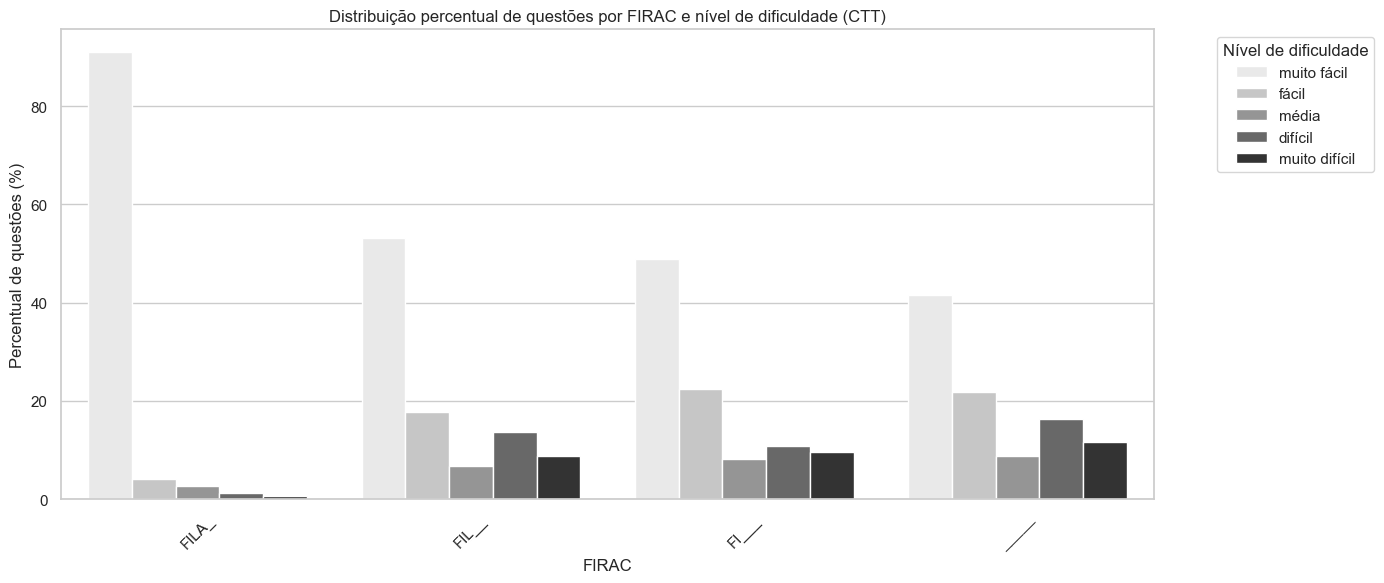

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Função de classificação CTT ---
def classify_difficulty(acc):
    if acc >= 0.80:
        return 'muito fácil'
    elif acc >= 0.60:
        return 'fácil'
    elif acc >= 0.40:
        return 'média'
    elif acc >= 0.20:
        return 'difícil'
    else:
        return 'muito difícil'

# --- Calcula acurácia por questão ---
df_question = (
    question_long_df.groupby(['question_id', 'firac'])['is_correct']
    .mean()
    .reset_index(name='accuracy')
)

# --- Garante que firac seja coluna ---
df_question['firac'] = df_question['firac'].fillna('UNKNOWN').astype(str)

# --- Classifica dificuldade pelo CTT ---
df_question['difficulty'] = df_question['accuracy'].apply(classify_difficulty)

# --- Calcula porcentagens por FIRAC usando value_counts(normalize=True) ---
df_pct = (
    df_question
    .groupby('firac')['difficulty']
    .value_counts(normalize=True)   # retorna proporção
    .mul(100)                       # converte para %
    .rename('percent')
    .reset_index()
)

# --- Plot ---
plt.figure(figsize=(14, 6))
sns.set(style="whitegrid")

sns.barplot(
    data=df_pct,
    x='firac',
    y='percent',
    hue='difficulty',
    hue_order=['muito fácil', 'fácil', 'média', 'difícil', 'muito difícil'],
    order=firac_order,
    palette='Greys'
)

plt.title('Distribuição percentual de questões por FIRAC e nível de dificuldade (CTT)')
plt.xlabel('FIRAC')
plt.ylabel('Percentual de questões (%)')
plt.xticks(rotation=45)
plt.legend(title='Nível de dificuldade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd
from scipy.stats import pointbiserialr

def compute_question_biserial(question_long_df, firac_order=None):
    """
    Calcula point-biserial correlation para cada question_id e firac.
    Retorna DataFrame wide: linhas = question_id, colunas = firac, valores = pointbiserialr
    - firac_order: lista opcional com a ordem desejada das colunas firac
    """
    biserial_records = []

    # Itera por cada firac
    for firac, df_firac in question_long_df.groupby('firac'):
        # Calcula pontuação total do modelo por model_name
        total_score_df = (
            df_firac.groupby('model_name')['is_correct'].mean().reset_index(name='total_score')
        )

        # Junta com df_firac
        df_firac_merged = df_firac.merge(total_score_df, on='model_name', how='left')

        # Para cada question_id dentro deste firac
        for question_id, df_q in df_firac_merged.groupby('question_id'):
            # Evita divisões por zero ou variância nula
            if df_q['is_correct'].nunique() < 2 or df_q['total_score'].nunique() < 2:
                r = float('nan')
            else:
                r, _ = pointbiserialr(df_q['is_correct'], df_q['total_score'])
            biserial_records.append({
                'question_id': question_id,
                'firac': firac,
                'biserial': r
            })

    # Constrói DataFrame wide
    biserial_df = pd.DataFrame(biserial_records)
    question_biserial_df = biserial_df.pivot(index='question_id', columns='firac', values='biserial')

    # Ordena as linhas pelo valor da coluna firac "____"
    if '____' in question_biserial_df.columns:
        question_biserial_df = question_biserial_df.sort_values(by='____', ascending=False)

    # Reordena as colunas se firac_order for fornecido
    if firac_order is not None:
        # Mantém apenas os firac que existem no DataFrame
        firac_order_filtered = [f for f in firac_order if f in question_biserial_df.columns]
        question_biserial_df = question_biserial_df[firac_order_filtered]

    return question_biserial_df

# Exemplo de uso

question_biserial_df = compute_question_biserial(question_long_df, firac_order=firac_order)
question_biserial_df.head(100)
    

firac,FILA_,FIL__,FI___,_____
question_id,,,,
oab-153.pdf-007,NaN,0.995434,NaN,0.954145
oab-153.pdf-014,NaN,0.734702,1.000000,0.736312
oab-154.pdf-019,NaN,NaN,NaN,NaN
oab-154.pdf-021,NaN,NaN,NaN,NaN
oab-154.pdf-023,NaN,NaN,NaN,NaN
...,...,...,...,...
oab-178.pdf-261,NaN,NaN,NaN,NaN
oab-178.pdf-262,NaN,NaN,NaN,NaN
oab-178.pdf-264,NaN,NaN,-0.126838,0.066809


In [11]:
import pandas as pd
from scipy.stats import pointbiserialr

def compute_question_biserial_pvalue(question_long_df, firac_order=None):
    """
    Calcula point-biserial correlation p-value para cada question_id e firac.
    Retorna DataFrame wide: linhas = question_id, colunas = firac, valores = p-value
    - firac_order: lista opcional com a ordem desejada das colunas firac
    """
    pvalue_records = []

    # Itera por cada firac
    for firac, df_firac in question_long_df.groupby('firac'):
        # Calcula pontuação total do modelo por model_name
        total_score_df = (
            df_firac.groupby('model_name')['is_correct'].mean().reset_index(name='total_score')
        )

        # Junta com df_firac
        df_firac_merged = df_firac.merge(total_score_df, on='model_name', how='left')

        # Para cada question_id dentro deste firac
        for question_id, df_q in df_firac_merged.groupby('question_id'):
            # Evita divisões por zero ou variância nula
            if df_q['is_correct'].nunique() < 2 or df_q['total_score'].nunique() < 2:
                p = float('nan')
            else:
                _, p = pointbiserialr(df_q['is_correct'], df_q['total_score'])
            pvalue_records.append({
                'question_id': question_id,
                'firac': firac,
                'pvalue': p
            })

    # Constrói DataFrame wide
    pvalue_df = pd.DataFrame(pvalue_records)
    question_pvalue_df = pvalue_df.pivot(index='question_id', columns='firac', values='pvalue')

    # Ordena as linhas pelo valor da coluna firac "____"
    if '____' in question_pvalue_df.columns:
        question_pvalue_df = question_pvalue_df.sort_values(by='____', ascending=False)

    # Reordena as colunas se firac_order for fornecido
    if firac_order is not None:
        firac_order_filtered = [f for f in firac_order if f in question_pvalue_df.columns]
        question_pvalue_df = question_pvalue_df[firac_order_filtered]

    return question_pvalue_df

# Exemplo de uso
question_pvalue_df = compute_question_biserial_pvalue(question_long_df, firac_order=firac_order)
question_pvalue_df.head(100)


firac,FILA_,FIL__,FI___,_____
question_id,,,,
oab-153.pdf-007,NaN,0.060859,NaN,0.193536
oab-153.pdf-014,NaN,0.265298,1.000000,0.473131
oab-154.pdf-019,NaN,NaN,NaN,NaN
oab-154.pdf-021,NaN,NaN,NaN,NaN
oab-154.pdf-023,NaN,NaN,NaN,NaN
...,...,...,...,...
oab-178.pdf-261,NaN,NaN,NaN,NaN
oab-178.pdf-262,NaN,NaN,NaN,NaN
oab-178.pdf-264,NaN,NaN,0.919034,0.957436


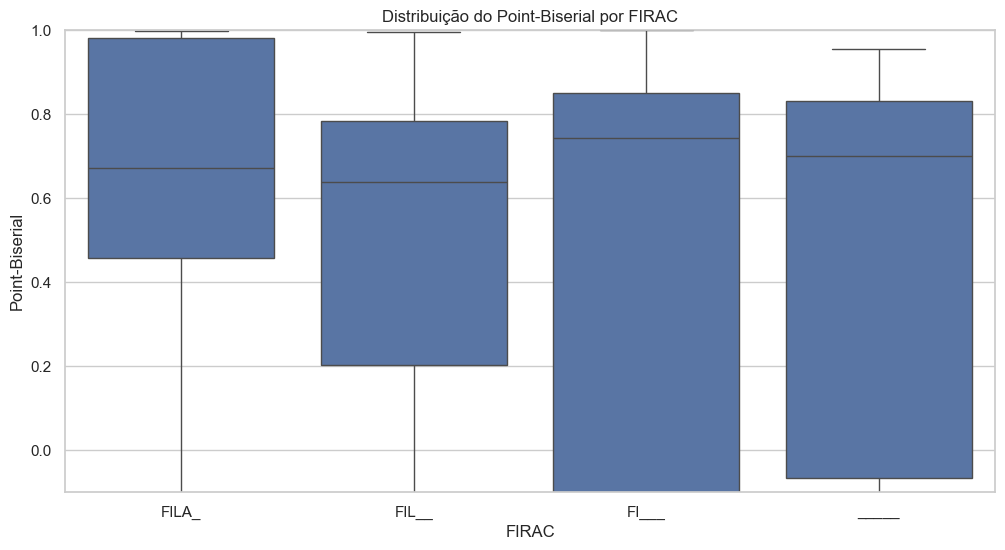

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Transforma wide para long
biserial_long_df = question_biserial_df.reset_index().melt(
    id_vars='question_id', 
    var_name='firac', 
    value_name='biserial'
)

# Remove NaNs (caso existam)
biserial_long_df = biserial_long_df.dropna(subset=['biserial'])

# Plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

sns.boxplot(
    data=biserial_long_df,
    x='firac',
    y='biserial',
    order=question_biserial_df.columns  # mantém a ordem das colunas
)

plt.title('Distribuição do Point-Biserial por FIRAC')
plt.xlabel('FIRAC')
plt.ylabel('Point-Biserial')
plt.ylim(-0.1, 1)  # opcional: limita eixo Y para melhor visualização
plt.show()
